In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

In [ ]:
pd.set_option("display.max_columns", None)

pd.set_option("display.float_format", "{:.2f}".format)

In [ ]:
PROJECT_ROOT = Path("..")

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw"

PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed"

PROCESSED_DATA_PATH.mkdir(parents=True, exist_ok=True)

PREPARATION_FIGURES_PATH = PROJECT_ROOT / "figures" / "03_preparacion"

PREPARATION_FIGURES_PATH.mkdir(parents=True, exist_ok=True)

In [4]:
train = pd.read_csv(RAW_DATA_PATH / "train.csv")

stores = pd.read_csv(RAW_DATA_PATH / "stores.csv")

oil = pd.read_csv(RAW_DATA_PATH / "oil.csv")

holidays = pd.read_csv(RAW_DATA_PATH / "holidays_events.csv")

transactions = pd.read_csv(RAW_DATA_PATH / "transactions.csv")

test = pd.read_csv(RAW_DATA_PATH / "test.csv")

In [ ]:
train["date"] = pd.to_datetime(train["date"])

test["date"] = pd.to_datetime(test["date"])

oil["date"] = pd.to_datetime(oil["date"])

holidays["date"] = pd.to_datetime(holidays["date"])

transactions["date"] = pd.to_datetime(transactions["date"])

In [ ]:
datasets = {
    "train": train,
    "stores": stores,
    "oil": oil,
    "holidays": holidays,
    "transactions": transactions,
    "test": test,
}

for name, df in datasets.items():
    print(f"{name:<15} {df.shape}")

train           (3000888, 6)
stores          (54, 5)
oil             (1218, 2)
holidays        (350, 6)
transactions    (83488, 3)
test            (28512, 5)


In [ ]:
for name, df in datasets.items():
    print("=" * 80)
    print(name.upper())
    display(df.head())

TRAIN


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.00,0
1,1,2013-01-01,1,BABY CARE,0.00,0
2,2,2013-01-01,1,BEAUTY,0.00,0
3,3,2013-01-01,1,BEVERAGES,0.00,0
4,4,2013-01-01,1,BOOKS,0.00,0


STORES


,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


OIL


...

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


TRANSACTIONS


,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


TEST


,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2
3,3000891,2017-08-16,1,BEVERAGES,20
4,3000892,2017-08-16,1,BOOKS,0


In [ ]:
train_clean = train.copy()
test_clean = test.copy()
stores_clean = stores.copy()
oil_clean = oil.copy()
holidays_clean = holidays.copy()
transactions_clean = transactions.copy()

In [ ]:
datasets_clean = {
    "train": train_clean,
    "test": test_clean,
    "stores": stores_clean,
    "oil": oil_clean,
    "holidays": holidays_clean,
    "transactions": transactions_clean,
}

for name, df in datasets_clean.items():
    print("=" * 80)
    print(name.upper())
    print(df.dtypes)

TRAIN
id                      int64
date           datetime64[ns]
store_nbr               int64
family                 object
sales                 float64
onpromotion             int64
dtype: object
TEST
id                      int64
date           datetime64[ns]
store_nbr               int64
family                 object
onpromotion             int64
dtype: object
STORES
store_nbr     int64
city         object
state        object
type         object
cluster       int64
dtype: object
OIL
date          datetime64[ns]
dcoilwtico           float64
dtype: object
HOLIDAYS
date           datetime64[ns]
type                   object
locale                 object
locale_name            object
description            object
transferred              bool
dtype: object
TRANSACTIONS
date            datetime64[ns]
store_nbr                int64
transactions             int64
dtype: object


In [10]:
dataframes_with_date = [
    train_clean,
    test_clean,
    oil_clean,
    holidays_clean,
    transactions_clean,
]

for df in dataframes_with_date:
    df["date"] = pd.to_datetime(df["date"])

In [11]:
train_clean["store_nbr"] = train_clean["store_nbr"].astype("int16")
test_clean["store_nbr"] = test_clean["store_nbr"].astype("int16")
stores_clean["store_nbr"] = stores_clean["store_nbr"].astype("int16")
transactions_clean["store_nbr"] = transactions_clean["store_nbr"].astype("int16")

train_clean["onpromotion"] = train_clean["onpromotion"].astype("int32")
test_clean["onpromotion"] = test_clean["onpromotion"].astype("int32")
transactions_clean["transactions"] = transactions_clean["transactions"].astype("int32")

In [12]:
train_clean["sales"] = train_clean["sales"].astype("float32")
oil_clean["dcoilwtico"] = oil_clean["dcoilwtico"].astype("float32")

In [13]:
for name, df in datasets_clean.items():
    print("=" * 80)
    print(name.upper())
    print(df.dtypes)

TRAIN
id                      int64
date           datetime64[ns]
store_nbr               int16
family                 object
sales                 float32
onpromotion             int32
dtype: object
TEST
id                      int64
date           datetime64[ns]
store_nbr               int16
family                 object
onpromotion             int32
dtype: object
STORES
store_nbr     int16
city         object
state        object
type         object
cluster       int64
dtype: object
OIL
date          datetime64[ns]
dcoilwtico           float32
dtype: object
HOLIDAYS
date           datetime64[ns]
type                   object
locale                 object
locale_name            object
description            object
transferred              bool
dtype: object
TRANSACTIONS
date            datetime64[ns]
store_nbr                int16
transactions             int32
dtype: object


In [ ]:
duplicate_summary = []

for name, df in datasets_clean.items():
    duplicate_summary.append(
        {
            "dataset": name,
            "rows": len(df),
            "complete_duplicates": int(df.duplicated().sum()),
        }
    )

duplicate_summary = pd.DataFrame(duplicate_summary)
duplicate_summary

,dataset,rows,complete_duplicates
0,train,3000888,0
1,test,28512,0
2,stores,54,0
3,oil,1218,0
4,holidays,350,0
5,transactions,83488,0


In [15]:
primary_keys = {
    "train": ["date", "store_nbr", "family"],
    "test": ["date", "store_nbr", "family"],
    "stores": ["store_nbr"],
    "oil": ["date"],
    "transactions": ["date", "store_nbr"],
}

In [16]:
key_duplicate_summary = []

for name, keys in primary_keys.items():
    df = datasets_clean[name]

    key_duplicate_summary.append(
        {
            "dataset": name,
            "key": ", ".join(keys),
            "duplicated_keys": int(df.duplicated(subset=keys).sum()),
        }
    )

key_duplicate_summary = pd.DataFrame(key_duplicate_summary)
key_duplicate_summary

,dataset,key,duplicated_keys
0,train,"date, store_nbr, family",0
1,test,"date, store_nbr, family",0
2,stores,store_nbr,0
3,oil,date,0
4,transactions,"date, store_nbr",0


In [17]:
holidays_clean[
    holidays_clean.duplicated(subset=["date"], keep=False)
].sort_values("date").head(20)

,date,type,locale,locale_name,description,transferred
7,2012-06-25,Holiday,Regional,Imbabura,Provincializacion de Imbabura,False
8,2012-06-25,Holiday,Local,Latacunga,Cantonizacion de Latacunga,False
9,2012-06-25,Holiday,Local,Machala,Fundacion de Machala,False
10,2012-07-03,Holiday,Local,Santo Domingo,Fundacion de Santo Domingo,False
11,2012-07-03,Holiday,Local,El Carmen,Cantonizacion de El Carmen,False
32,2012-12-22,Holiday,Local,Salinas,Cantonizacion de Salinas,False
33,2012-12-22,Additional,National,Ecuador,Navidad-3,False
36,2012-12-24,Additional,National,Ecuador,Navidad-1,False
35,2012-12-24,Bridge,National,Ecuador,Puente Navidad,False
39,2012-12-31,Bridge,National,Ecuador,Puente Primer dia del ano,False


In [ ]:
train_clean = train_clean.drop_duplicates().reset_index(drop=True)
test_clean = test_clean.drop_duplicates().reset_index(drop=True)
stores_clean = stores_clean.drop_duplicates().reset_index(drop=True)
oil_clean = oil_clean.drop_duplicates().reset_index(drop=True)
holidays_clean = holidays_clean.drop_duplicates().reset_index(drop=True)
transactions_clean = transactions_clean.drop_duplicates().reset_index(drop=True)

In [19]:
## Valores nulos

null_summary = []

for name, df in datasets_clean.items():
    for column in df.columns:
        n_nulls = int(df[column].isna().sum())

        if n_nulls > 0:
            null_summary.append(
                {
                    "dataset": name,
                    "column": column,
                    "nulls": n_nulls,
                    "percentage": n_nulls / len(df) * 100,
                }
            )

null_summary = pd.DataFrame(null_summary)
null_summary

,dataset,column,nulls,percentage
0,oil,dcoilwtico,43,3.53


In [20]:
oil_clean[oil_clean["dcoilwtico"].isna()].head(20)

,date,dcoilwtico
0,2013-01-01,NaN
14,2013-01-21,NaN
34,2013-02-18,NaN
63,2013-03-29,NaN
104,2013-05-27,NaN
132,2013-07-04,NaN
174,2013-09-02,NaN
237,2013-11-28,NaN
256,2013-12-25,NaN
261,2014-01-01,NaN


In [21]:
print("Número de valores nulos:")
print(oil_clean["dcoilwtico"].isna().sum())

print("\nPorcentaje de valores nulos:")
print(oil_clean["dcoilwtico"].isna().mean() * 100)

Número de valores nulos:
43

Porcentaje de valores nulos:
3.5303776683087027


In [ ]:
## valores nulos del petróleo

oil_clean = oil_clean.sort_values("date").reset_index(drop=True)

oil_daily = (
    oil_clean
    .set_index("date")
    .sort_index()
    .reindex(
        pd.date_range(
            start=oil_clean["date"].min(),
            end=oil_clean["date"].max(),
            freq="D"
        )
    )
)

oil_daily.index.name = "date"
oil_daily.head()

,dcoilwtico
date,
2013-01-01,NaN
2013-01-02,93.14
2013-01-03,92.97
2013-01-04,93.12
2013-01-05,NaN


In [23]:
## Método 1: Propagación del último valor conocido
oil_daily["oil_ffill"] = oil_daily["dcoilwtico"].ffill()

## Método 2: Interpolación temporal
oil_daily["oil_interpolation"] = (
    oil_daily["dcoilwtico"]
    .interpolate(method="time")
)

## Método 3: Interpolación y propagación
oil_daily["oil_combined"] = (
    oil_daily["dcoilwtico"]
    .interpolate(method="time")
    .ffill()
    .bfill()
)

In [24]:
## Comparación de los resultados

oil_methods_comparison = pd.DataFrame(
    {
        "method": [
            "Original",
            "Forward fill",
            "Interpolación temporal",
            "Combinación"
        ],
        "remaining_nulls": [
            oil_daily["dcoilwtico"].isna().sum(),
            oil_daily["oil_ffill"].isna().sum(),
            oil_daily["oil_interpolation"].isna().sum(),
            oil_daily["oil_combined"].isna().sum(),
        ],
    }
)

oil_methods_comparison

,method,remaining_nulls
0,Original,529
1,Forward fill,1
2,Interpolación temporal,1
3,Combinación,0


In [ ]:
oil_daily.loc[
    oil_daily["dcoilwtico"].isna(),
    [
        "dcoilwtico",
        "oil_ffill",
        "oil_interpolation",
        "oil_combined"
    ]
].head(20)

,dcoilwtico,oil_ffill,oil_interpolation,oil_combined
date,,,,
2013-01-01,NaN,NaN,NaN,93.14
2013-01-05,NaN,93.12,93.15,93.15
2013-01-06,NaN,93.12,93.17,93.17
2013-01-12,NaN,93.60,93.82,93.82
2013-01-13,NaN,93.60,94.05,94.05
2013-01-19,NaN,95.61,95.73,95.73
2013-01-20,NaN,95.61,95.85,95.85
2013-01-21,NaN,95.61,95.97,95.97
2013-01-26,NaN,95.15,95.42,95.42


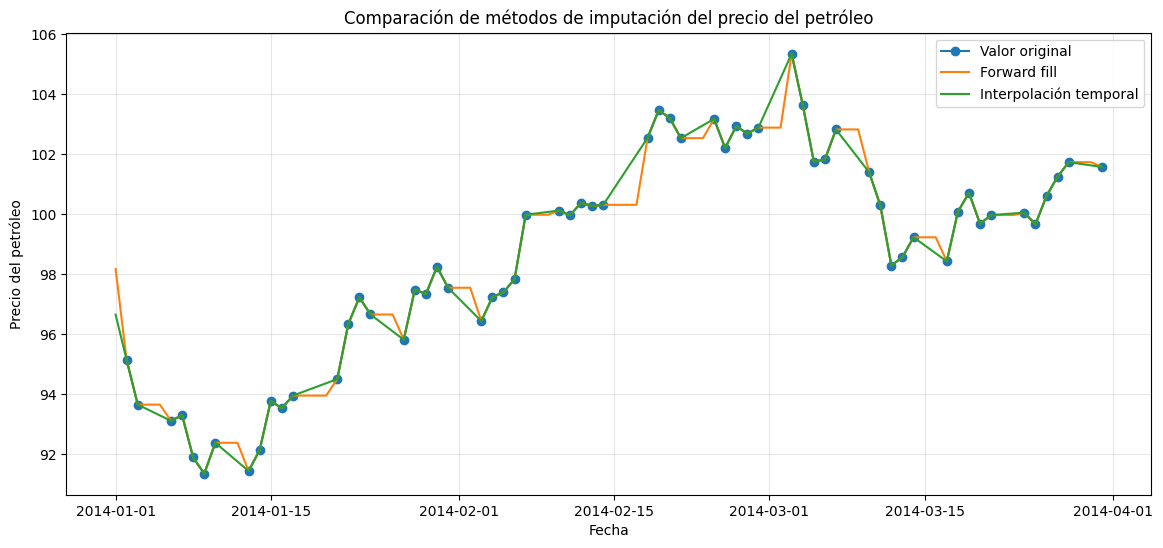

In [ ]:
import matplotlib.pyplot as plt

oil_sample = oil_daily.loc["2014-01-01":"2014-03-31"]

plt.figure(figsize=(14, 6))

plt.plot(
    oil_sample.index,
    oil_sample["dcoilwtico"],
    marker="o",
    label="Valor original"
)

plt.plot(
    oil_sample.index,
    oil_sample["oil_ffill"],
    label="Forward fill"
)

plt.plot(
    oil_sample.index,
    oil_sample["oil_interpolation"],
    label="Interpolación temporal"
)

plt.title("Comparación de métodos de imputación del precio del petróleo")
plt.xlabel("Fecha")
plt.ylabel("Precio del petróleo")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    PREPARATION_FIGURES_PATH / "comparacion_imputacion_petroleo.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [ ]:
oil_prepared = (
    oil_daily[["oil_ffill"]]
    .rename(columns={"oil_ffill": "oil_price"})
    .reset_index()
)

In [28]:
oil_prepared["oil_price"] = oil_prepared["oil_price"].bfill()

In [ ]:
oil_prepared.info()
print("\n")
oil_prepared.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       1704 non-null   datetime64[ns]
 1   oil_price  1704 non-null   float32       
dtypes: datetime64[ns](1), float32(1)
memory usage: 20.1 KB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       1704 non-null   datetime64[ns]
 1   oil_price  1704 non-null   float32       
dtypes: datetime64[ns](1), float32(1)
memory usage: 20.1 KB


In [ ]:
full_train_dates = pd.date_range(
    start=train_clean["date"].min(),
    end=train_clean["date"].max(),
    freq="D"
)

observed_train_dates = pd.DatetimeIndex(
    train_clean["date"].drop_duplicates().sort_values()
)

missing_train_dates = full_train_dates.difference(observed_train_dates)

print("Fecha inicial:", train_clean["date"].min())
print("Fecha final:", train_clean["date"].max())
print("Número de días esperados:", len(full_train_dates))
print("Número de días observados:", len(observed_train_dates))
print("Número de fechas ausentes:", len(missing_train_dates))

Fecha inicial: 2013-01-01 00:00:00
Fecha final: 2017-08-15 00:00:00
Número de días esperados: 1688
Número de días observados: 1684
Número de fechas ausentes: 4


In [31]:
missing_train_dates

DatetimeIndex(['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25'], dtype='datetime64[ns]', freq=None)

In [ ]:
# cuántas observaciones existen por fecha.

n_stores = train_clean["store_nbr"].nunique()
n_families = train_clean["family"].nunique()
expected_rows_per_date = n_stores * n_families

print("Tiendas:", n_stores)
print("Familias:", n_families)
print("Observaciones esperadas por fecha:", expected_rows_per_date)

Tiendas: 54
Familias: 33
Observaciones esperadas por fecha: 1782


In [33]:
rows_per_date = (
    train_clean
    .groupby("date")
    .size()
    .rename("observed_rows")
    .reset_index()
)

rows_per_date["expected_rows"] = expected_rows_per_date
rows_per_date["missing_combinations"] = (
    rows_per_date["expected_rows"] - rows_per_date["observed_rows"]
)

rows_per_date.head()

,date,observed_rows,expected_rows,missing_combinations
0,2013-01-01,1782,1782,0
1,2013-01-02,1782,1782,0
2,2013-01-03,1782,1782,0
3,2013-01-04,1782,1782,0
4,2013-01-05,1782,1782,0


In [34]:
## Fechas con combinaciones incompletas:

incomplete_dates = rows_per_date[
    rows_per_date["missing_combinations"] > 0
]

print("Fechas con panel incompleto:", len(incomplete_dates))
incomplete_dates.head(20)

Fechas con panel incompleto: 0


,date,observed_rows,expected_rows,missing_combinations


In [ ]:
## También comprobar la regularidad por serie.

series_date_summary = (
    train_clean
    .groupby(["store_nbr", "family"])
    .agg(
        min_date=("date", "min"),
        max_date=("date", "max"),
        observed_days=("date", "nunique")
    )
    .reset_index()
)

series_date_summary["expected_days"] = (
    series_date_summary["max_date"]
    - series_date_summary["min_date"]
).dt.days + 1

series_date_summary["missing_days"] = (
    series_date_summary["expected_days"]
    - series_date_summary["observed_days"]
)

series_date_summary["missing_days"].describe()

count   1782.00
mean       4.00
std        0.00
min        4.00
25%        4.00
50%        4.00
75%        4.00
max        4.00
Name: missing_days, dtype: float64

In [ ]:
series_date_summary[
    series_date_summary["missing_days"] > 0
].sort_values("missing_days", ascending=False).head(20)

,store_nbr,family,min_date,max_date,observed_days,expected_days,missing_days
0,1,AUTOMOTIVE,2013-01-01,2017-08-15,1684,1688,4
1184,36,PREPARED FOODS,2013-01-01,2017-08-15,1684,1688,4
1195,37,CLEANING,2013-01-01,2017-08-15,1684,1688,4
1194,37,CELEBRATION,2013-01-01,2017-08-15,1684,1688,4
1193,37,BREAD/BAKERY,2013-01-01,2017-08-15,1684,1688,4
1192,37,BOOKS,2013-01-01,2017-08-15,1684,1688,4
1191,37,BEVERAGES,2013-01-01,2017-08-15,1684,1688,4
1190,37,BEAUTY,2013-01-01,2017-08-15,1684,1688,4
1189,37,BABY CARE,2013-01-01,2017-08-15,1684,1688,4
1188,37,AUTOMOTIVE,2013-01-01,2017-08-15,1684,1688,4


In [ ]:
## Festivos trasladados
holidays_clean["transferred"].value_counts(dropna=False)

holidays_clean[
    holidays_clean["transferred"]
].sort_values("date").head(20)

,date,type,locale,locale_name,description,transferred
19,2012-10-09,Holiday,National,Ecuador,Independencia de Guayaquil,True
72,2013-10-09,Holiday,National,Ecuador,Independencia de Guayaquil,True
135,2014-10-09,Holiday,National,Ecuador,Independencia de Guayaquil,True
255,2016-05-24,Holiday,National,Ecuador,Batalla de Pichincha,True
266,2016-07-25,Holiday,Local,Guayaquil,Fundacion de Guayaquil,True
268,2016-08-10,Holiday,National,Ecuador,Primer Grito de Independencia,True
297,2017-01-01,Holiday,National,Ecuador,Primer dia del ano,True
303,2017-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,True
312,2017-05-24,Holiday,National,Ecuador,Batalla de Pichincha,True
324,2017-08-10,Holiday,National,Ecuador,Primer Grito de Independencia,True


In [ ]:
holidays_clean["type"].value_counts(dropna=False)

type
Holiday       221
Event          56
Additional     51
Transfer       12
Bridge          5
Work Day        5
Name: count, dtype: int64

In [ ]:
holidays_effective = holidays_clean[
    holidays_clean["transferred"] == False
].copy()

In [ ]:
holidays_effective = holidays_effective.drop(columns="transferred")

In [ ]:
holidays_effective.head()
holidays_effective["type"].value_counts()

type
Holiday       209
Event          56
Additional     51
Transfer       12
Bridge          5
Work Day        5
Name: count, dtype: int64

In [ ]:
## Variables categóricas

categorical_columns = {
    "train": ["family"],
    "test": ["family"],
    "stores": ["city", "state", "type"],
    "holidays": ["type", "locale", "locale_name", "description"],
}

In [ ]:
for dataset_name, columns in categorical_columns.items():
    df = {
        "train": train_clean,
        "test": test_clean,
        "stores": stores_clean,
        "holidays": holidays_effective,
    }[dataset_name]

    print("=" * 80)
    print(dataset_name.upper())

    for column in columns:
        print(f"\n{column}: {df[column].nunique()} categorías")
        print(df[column].value_counts(dropna=False).head(10))

TRAIN

family: 33 categorías
family
AUTOMOTIVE                    90936
HOME APPLIANCES               90936
SCHOOL AND OFFICE SUPPLIES    90936
PRODUCE                       90936
PREPARED FOODS                90936
POULTRY                       90936
PLAYERS AND ELECTRONICS       90936
PET SUPPLIES                  90936
PERSONAL CARE                 90936
MEATS                         90936
Name: count, dtype: int64
TEST

family: 33 categorías
family
AUTOMOTIVE                    864
HOME APPLIANCES               864
SCHOOL AND OFFICE SUPPLIES    864
PRODUCE                       864
PREPARED FOODS                864
POULTRY                       864
PLAYERS AND ELECTRONICS       864
PET SUPPLIES                  864
PERSONAL CARE                 864
MEATS                         864
Name: count, dtype: int64
STORES

city: 22 categorías
city
Quito            18
Guayaquil         8
Cuenca            3
Santo Domingo     3
Manta             2
Latacunga         2
Machala           2
Amba

In [44]:
# Ventas iguales a cero
zero_sales_count = (train_clean["sales"] == 0).sum()
zero_sales_percentage = (train_clean["sales"] == 0).mean() * 100

print("Ventas iguales a cero:", zero_sales_count)
print(f"Porcentaje: {zero_sales_percentage:.2f}%")

Ventas iguales a cero: 939130
Porcentaje: 31.30%


In [45]:
# Distribución de ceros por familia:

zero_sales_by_family = (
    train_clean
    .assign(is_zero_sale=train_clean["sales"].eq(0))
    .groupby("family", observed=True)
    .agg(
        observations=("sales", "size"),
        zero_sales=("is_zero_sale", "sum"),
        zero_percentage=("is_zero_sale", "mean")
    )
    .reset_index()
)

zero_sales_by_family["zero_percentage"] *= 100

zero_sales_by_family.sort_values(
    "zero_percentage",
    ascending=False
).head(15)

,family,observations,zero_sales,zero_percentage
4,BOOKS,90936,88167,96.96
1,BABY CARE,90936,85599,94.13
31,SCHOOL AND OFFICE SUPPLIES,90936,67368,74.08
17,HOME APPLIANCES,90936,66854,73.52
19,LADIESWEAR,90936,54422,59.85
23,MAGAZINES,90936,51414,56.54
26,PET SUPPLIES,90936,49665,54.62
14,HARDWARE,90936,43524,47.86
20,LAWN AND GARDEN,90936,42544,46.78
27,PLAYERS AND ELECTRONICS,90936,40818,44.89


In [46]:
# Distribución por tienda:

zero_sales_by_store = (
    train_clean
    .assign(is_zero_sale=train_clean["sales"].eq(0))
    .groupby("store_nbr")
    .agg(
        observations=("sales", "size"),
        zero_sales=("is_zero_sale", "sum"),
        zero_percentage=("is_zero_sale", "mean")
    )
    .reset_index()
)

zero_sales_by_store["zero_percentage"] *= 100

zero_sales_by_store.sort_values(
    "zero_percentage",
    ascending=False
).head(15)

,store_nbr,observations,zero_sales,zero_percentage
51,52,55572,51982,93.54
21,22,55572,38094,68.55
41,42,55572,34575,62.22
20,21,55572,34066,61.30
28,29,55572,31797,57.22
19,20,55572,30271,54.47
52,53,55572,24028,43.24
31,32,55572,21995,39.58
34,35,55572,21738,39.12
53,54,55572,19310,34.75


In [ ]:
assert (train_clean["sales"] == 0).any()

In [ ]:
train_clean["sales"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999]
)

count   3000888.00
mean        357.78
std        1102.00
min           0.00
1%            0.00
5%            0.00
25%           0.00
50%          11.00
75%         195.85
95%        1965.00
99%        5507.00
99.9%     12076.23
max      124717.00
Name: sales, dtype: float64

In [ ]:
q1 = train_clean["sales"].quantile(0.25)
q3 = train_clean["sales"].quantile(0.75)
iqr = q3 - q1

lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

global_outlier_mask = (
    (train_clean["sales"] < lower_limit)
    | (train_clean["sales"] > upper_limit)
)

print("Límite inferior:", lower_limit)
print("Límite superior:", upper_limit)
print("Posibles valores extremos:", global_outlier_mask.sum())
print(
    "Porcentaje:",
    global_outlier_mask.mean() * 100
)

Límite inferior: -293.77087783813477
Límite superior: 489.6181297302246
Posibles valores extremos: 447105
Porcentaje: 14.899089869398658


In [ ]:
family_limits = (
    train_clean
    .groupby("family", observed=True)["sales"]
    .quantile([0.25, 0.75])
    .unstack()
    .rename(columns={0.25: "q1", 0.75: "q3"})
)

family_limits["iqr"] = family_limits["q3"] - family_limits["q1"]
family_limits["lower_limit"] = (
    family_limits["q1"] - 1.5 * family_limits["iqr"]
)
family_limits["upper_limit"] = (
    family_limits["q3"] + 1.5 * family_limits["iqr"]
)

family_limits.head()

,q1,q3,iqr,lower_limit,upper_limit
family,,,,,
AUTOMOTIVE,2.00,8.00,6.00,-7.00,17.00
BABY CARE,0.00,0.00,0.00,0.00,0.00
BEAUTY,0.00,5.00,5.00,-7.50,12.50
BEVERAGES,897.00,3119.00,2222.00,-2436.00,6452.00
BOOKS,0.00,0.00,0.00,0.00,0.00


In [ ]:
train_outlier_analysis = train_clean.merge(
    family_limits[["lower_limit", "upper_limit"]],
    left_on="family",
    right_index=True,
    how="left"
)
train_outlier_analysis["is_outlier_iqr"] = (
    (
        train_outlier_analysis["sales"]
        < train_outlier_analysis["lower_limit"]
    )
    |
    (
        train_outlier_analysis["sales"]
        > train_outlier_analysis["upper_limit"]
    )
)
print(
    "Posibles valores extremos por familia:",
    train_outlier_analysis["is_outlier_iqr"].sum()
)

print(
    "Porcentaje:",
    train_outlier_analysis["is_outlier_iqr"].mean() * 100
)

Posibles valores extremos por familia: 200274
Porcentaje: 6.673824547933811


In [ ]:
train_outlier_analysis[
    train_outlier_analysis["is_outlier_iqr"]
].sort_values("sales", ascending=False).head(20)

,id,date,store_nbr,family,sales,onpromotion,lower_limit,upper_limit,is_outlier_iqr
2163723,2163723,2016-05-02,2,GROCERY I,124717.00,59,-1796.50,8639.50,True
2445984,2445984,2016-10-07,39,MEATS,89576.36,0,-383.97,962.38,True
2144154,2144154,2016-04-21,20,GROCERY I,87438.52,53,-1796.50,8639.50,True
2139699,2139699,2016-04-18,45,GROCERY I,76090.00,38,-1796.50,8639.50,True
2153031,2153031,2016-04-26,2,GROCERY I,63434.00,30,-1796.50,8639.50,True
2145045,2145045,2016-04-21,45,GROCERY I,53874.00,44,-1796.50,8639.50,True
562596,562596,2013-11-12,44,GROCERY I,46271.00,0,-1796.50,8639.50,True
1257246,1257246,2014-12-08,35,GROCERY I,45361.00,3,-1796.50,8639.50,True
1916586,1916586,2015-12-14,35,GROCERY I,40351.46,7,-1796.50,8639.50,True
2760297,2760297,2017-04-02,9,GROCERY I,38422.62,73,-1796.50,8639.50,True


In [ ]:
outliers_by_family = (
    train_outlier_analysis
    .groupby("family", observed=True)
    .agg(
        observations=("sales", "size"),
        possible_outliers=("is_outlier_iqr", "sum"),
        maximum_sales=("sales", "max")
    )
    .reset_index()
)

outliers_by_family["outlier_percentage"] = (
    outliers_by_family["possible_outliers"]
    / outliers_by_family["observations"]
    * 100
)

outliers_by_family.sort_values(
    "possible_outliers",
    ascending=False
).head(15)

,family,observations,possible_outliers,maximum_sales,outlier_percentage
31,SCHOOL AND OFFICE SUPPLIES,90936,13180,1332.00,14.49
23,MAGAZINES,90936,11998,79.00,13.19
19,LADIESWEAR,90936,9777,147.00,10.75
26,PET SUPPLIES,90936,9565,106.00,10.52
32,SEAFOOD,90936,8716,274.44,9.58
30,PRODUCE,90936,7575,17850.62,8.33
29,PREPARED FOODS,90936,7321,912.57,8.05
27,PLAYERS AND ELECTRONICS,90936,7097,269.00,7.80
28,POULTRY,90936,6938,12143.20,7.63
11,FROZEN FOODS,90936,6915,14541.55,7.60


In [ ]:
train_clean.shape

(3000888, 6)

In [ ]:
df_model = train_clean.copy()

initial_rows = len(df_model)

print("Filas iniciales:", initial_rows)
print("Columnas iniciales:", df_model.shape[1])

Filas iniciales: 3000888
Columnas iniciales: 6


In [ ]:
df_model = df_model.merge(
    stores_clean,
    on="store_nbr",
    how="left",
    validate="many_to_one"
)

assert len(df_model) == initial_rows
df_model[
    ["city", "state", "type", "cluster"]
].isna().sum()
df_model.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster
0,0,2013-01-01,1,AUTOMOTIVE,0.00,0,Quito,Pichincha,D,13
1,1,2013-01-01,1,BABY CARE,0.00,0,Quito,Pichincha,D,13
2,2,2013-01-01,1,BEAUTY,0.00,0,Quito,Pichincha,D,13
3,3,2013-01-01,1,BEVERAGES,0.00,0,Quito,Pichincha,D,13
4,4,2013-01-01,1,BOOKS,0.00,0,Quito,Pichincha,D,13


In [ ]:
df_model = df_model.merge(
    oil_prepared,
    on="date",
    how="left",
    validate="many_to_one"
)

In [ ]:
df_model["oil_price"].isna().sum()

0

In [ ]:
df_model = df_model.sort_values(
    ["date", "store_nbr", "family"]
).reset_index(drop=True)

oil_by_date = (
    df_model[["date", "oil_price"]]
    .drop_duplicates("date")
    .sort_values("date")
)

oil_by_date["oil_price"] = oil_by_date["oil_price"].ffill()

In [ ]:
oil_by_date["oil_price"] = oil_by_date["oil_price"].bfill()

In [ ]:
df_model = df_model.drop(columns="oil_price")

df_model = df_model.merge(
    oil_by_date,
    on="date",
    how="left",
    validate="many_to_one"
)

df_model["oil_price"].isna().sum()

0

In [ ]:
national_holidays = holidays_effective[
    holidays_effective["locale"] == "National"
].copy()

national_holidays = (
    national_holidays
    .groupby("date")
    .agg(
        national_holiday_type=(
            "type",
            lambda values: " | ".join(sorted(set(values)))
        ),
        national_holiday_description=(
            "description",
            lambda values: " | ".join(sorted(set(values)))
        )
    )
    .reset_index()
)

national_holidays["is_national_holiday"] = 1

In [ ]:
regional_holidays = holidays_effective[
    holidays_effective["locale"] == "Regional"
].copy()

regional_holidays = (
    regional_holidays
    .groupby(["date", "locale_name"])
    .agg(
        regional_holiday_type=(
            "type",
            lambda values: " | ".join(sorted(set(values)))
        ),
        regional_holiday_description=(
            "description",
            lambda values: " | ".join(sorted(set(values)))
        )
    )
    .reset_index()
    .rename(columns={"locale_name": "state"})
)

regional_holidays["is_regional_holiday"] = 1

In [ ]:
local_holidays = holidays_effective[
    holidays_effective["locale"] == "Local"
].copy()

local_holidays = (
    local_holidays
    .groupby(["date", "locale_name"])
    .agg(
        local_holiday_type=(
            "type",
            lambda values: " | ".join(sorted(set(values)))
        ),
        local_holiday_description=(
            "description",
            lambda values: " | ".join(sorted(set(values)))
        )
    )
    .reset_index()
    .rename(columns={"locale_name": "city"})
)

local_holidays["is_local_holiday"] = 1

In [ ]:
# Unión de los festivos nacionales

rows_before_holidays = len(df_model)

df_model = df_model.merge(
    national_holidays,
    on="date",
    how="left",
    validate="many_to_one"
)

assert len(df_model) == rows_before_holidays

# Unión de los festivos regionales

df_model = df_model.merge(
    regional_holidays,
    on=["date", "state"],
    how="left",
    validate="many_to_one"
)

assert len(df_model) == rows_before_holidays

# Unión de los festivos locales
df_model = df_model.merge(
    local_holidays,
    on=["date", "city"],
    how="left",
    validate="many_to_one"
)

assert len(df_model) == rows_before_holidays

In [66]:
[
    column
    for column in df_model.columns
    if "holiday" in column.lower()
]

['national_holiday_type',
 'national_holiday_description',
 'is_national_holiday',
 'regional_holiday_type',
 'regional_holiday_description',
 'is_regional_holiday',
 'local_holiday_type',
 'local_holiday_description',
 'is_local_holiday']

In [ ]:
holiday_indicator_columns = [
    "is_national_holiday",
    "is_regional_holiday",
    "is_local_holiday",
]

df_model[holiday_indicator_columns] = (
    df_model[holiday_indicator_columns]
    .fillna(0)
    .astype("int8")
)

In [ ]:
df_model["is_holiday"] = (
    df_model[holiday_indicator_columns]
    .max(axis=1)
    .astype("int8")
)

In [ ]:
df_model["is_work_day"] = (
    ~df_model["national_holiday_type"].eq("Work Day")
    & ~df_model["regional_holiday_type"].eq("Work Day")
    & ~df_model["local_holiday_type"].eq("Work Day")
).astype("int8")

In [ ]:
df_model["is_extra_work_day"] = (
    df_model[
        [
            "national_holiday_type",
            "regional_holiday_type",
            "local_holiday_type",
        ]
    ]
    .eq("Work Day")
    .any(axis=1)
    .astype("int8")
)

In [ ]:
df_model.loc[
    df_model["is_extra_work_day"] == 1,
    "is_holiday"
] = 0

In [ ]:
df_model[
    [
        "date",
        "store_nbr",
        "city",
        "state",
        "is_national_holiday",
        "is_regional_holiday",
        "is_local_holiday",
        "is_holiday",
        "is_extra_work_day",
    ]
].head()

,date,store_nbr,city,state,is_national_holiday,is_regional_holiday,is_local_holiday,is_holiday,is_extra_work_day
0,2013-01-01,1,Quito,Pichincha,1,0,0,1,0
1,2013-01-01,1,Quito,Pichincha,1,0,0,1,0
2,2013-01-01,1,Quito,Pichincha,1,0,0,1,0
3,2013-01-01,1,Quito,Pichincha,1,0,0,1,0
4,2013-01-01,1,Quito,Pichincha,1,0,0,1,0


In [ ]:
# =============================================================================
# 4.5. TRATAMIENTO DE LAS TRANSACCIONES
# =============================================================================

transactions_features = (
    transactions_clean
    .sort_values(["store_nbr", "date"])
    .copy()
)

In [ ]:
# -----------------------------------------------------------------------------
# Transacciones del día anterior
# -----------------------------------------------------------------------------

transactions_features["transactions_lag_1"] = (
    transactions_features
    .groupby("store_nbr")["transactions"]
    .shift(1)
)

In [ ]:
# -----------------------------------------------------------------------------
# Transacciones de hace exactamente 7 días
# -----------------------------------------------------------------------------

transactions_lag_7 = transactions_clean[
    ["date", "store_nbr", "transactions"]
].copy()

transactions_lag_7["date"] = (
    transactions_lag_7["date"] + pd.Timedelta(days=7)
)

transactions_lag_7 = transactions_lag_7.rename(
    columns={"transactions": "transactions_lag_7"}
)

In [ ]:
# -----------------------------------------------------------------------------
# Medias móviles de transacciones
# -----------------------------------------------------------------------------

transactions_features["transactions_rolling_mean_7"] = (
    transactions_features
    .groupby("store_nbr")["transactions"]
    .transform(
        lambda series: (
            series
            .shift(1)
            .rolling(window=7, min_periods=1)
            .mean()
        )
    )
)

transactions_features["transactions_rolling_mean_28"] = (
    transactions_features
    .groupby("store_nbr")["transactions"]
    .transform(
        lambda series: (
            series
            .shift(1)
            .rolling(window=28, min_periods=1)
            .mean()
        )
    )
)

transactions_features = transactions_features[
    [
        "date",
        "store_nbr",
        "transactions_lag_1",
        "transactions_rolling_mean_7",
        "transactions_rolling_mean_28",
    ]
]

rows_before_transactions = len(df_model)

df_model = df_model.merge(
    transactions_features,
    on=["date", "store_nbr"],
    how="left",
    validate="many_to_one"
)

df_model = df_model.merge(
    transactions_lag_7,
    on=["date", "store_nbr"],
    how="left",
    validate="many_to_one"
)

assert len(df_model) == rows_before_transactions, (
    "La unión con transacciones ha modificado el número de filas."
)

transaction_feature_columns = [
    "transactions_lag_1",
    "transactions_lag_7",
    "transactions_rolling_mean_7",
    "transactions_rolling_mean_28",
]

print("Valores nulos en las variables de transacciones:")
display(
    df_model[transaction_feature_columns]
    .isna()
    .sum()
    .to_frame("nulos")
)

Valores nulos en las variables de transacciones:


,nulos
transactions_lag_1,247566
transactions_lag_7,264891
transactions_rolling_mean_7,247566
transactions_rolling_mean_28,247566


In [ ]:
# =============================================================================
# 4.6. VARIABLES HISTÓRICAS DE VENTAS
# =============================================================================

import gc

df_model.sort_values(
    ["store_nbr", "family", "date"],
    inplace=True,
)

df_model.reset_index(
    drop=True,
    inplace=True,
)

group_keys = [
    "store_nbr",
    "family",
]

sales_group = df_model.groupby(
    group_keys,
    observed=True,
    sort=False,
)["sales"]


# -----------------------------------------------------------------------------
# Retardos de ventas
# -----------------------------------------------------------------------------

for lag in [1, 7, 14, 28]:

    df_model[f"sales_lag_{lag}"] = (
        sales_group
        .shift(lag)
        .astype("float32")
    )


# -----------------------------------------------------------------------------
# Medias móviles
# -----------------------------------------------------------------------------

sales_shifted = (
    sales_group
    .shift(1)
    .astype("float32")
)

for window in [7, 14, 28]:

    rolling_values = (
        sales_shifted
        .groupby(
            [
                df_model["store_nbr"],
                df_model["family"],
            ],
            observed=True,
            sort=False,
        )
        .rolling(
            window=window,
            min_periods=1,
        )
        .mean()
        .reset_index(
            level=[0, 1],
            drop=True,
        )
        .sort_index()
        .astype("float32")
    )

    df_model[
        f"sales_rolling_mean_{window}"
    ] = rolling_values


del sales_shifted
del rolling_values
del sales_group

gc.collect()


sales_history_columns = [
    "sales_lag_1",
    "sales_lag_7",
    "sales_lag_14",
    "sales_lag_28",
    "sales_rolling_mean_7",
    "sales_rolling_mean_14",
    "sales_rolling_mean_28",
]


print("Variables históricas de ventas creadas:")

display(
    df_model[sales_history_columns]
    .isna()
    .sum()
    .to_frame("nulos")
)

print(
    "Memoria de las variables históricas:",
    f"{df_model[sales_history_columns].memory_usage(deep=True).sum() / 1024**2:.2f} MB",
)

Variables históricas de ventas creadas:


,nulos
sales_lag_1,1782
sales_lag_7,12474
sales_lag_14,24948
sales_lag_28,49896
sales_rolling_mean_7,1782
sales_rolling_mean_14,1782
sales_rolling_mean_28,1782


Memoria de las variables históricas: 80.13 MB


In [ ]:
# =============================================================================
# 4.6. CREACIÓN DE VARIABLES TEMPORALES
# =============================================================================

df_model["year"] = df_model["date"].dt.year.astype("int16")
df_model["month"] = df_model["date"].dt.month.astype("int8")
df_model["day"] = df_model["date"].dt.day.astype("int8")
df_model["day_of_week"] = df_model["date"].dt.dayofweek.astype("int8")
df_model["day_of_year"] = df_model["date"].dt.dayofyear.astype("int16")
df_model["quarter"] = df_model["date"].dt.quarter.astype("int8")

df_model["week_of_year"] = (
    df_model["date"]
    .dt.isocalendar()
    .week
    .astype("int16")
)

df_model["is_weekend"] = (
    df_model["day_of_week"].isin([5, 6])
).astype("int8")


df_model["is_month_start"] = (
    df_model["date"].dt.is_month_start
).astype("int8")

df_model["is_month_end"] = (
    df_model["date"].dt.is_month_end
).astype("int8")

df_model["is_quarter_start"] = (
    df_model["date"].dt.is_quarter_start
).astype("int8")

df_model["is_quarter_end"] = (
    df_model["date"].dt.is_quarter_end
).astype("int8")

minimum_date = df_model["date"].min()

df_model["time_index"] = (
    df_model["date"] - minimum_date
).dt.days.astype("int16")

In [ ]:
# -----------------------------------------------------------------------------
# Variables temporales cíclicas
# -----------------------------------------------------------------------------

df_model["month_sin"] = np.sin(
    2 * np.pi * df_model["month"] / 12
)

df_model["month_cos"] = np.cos(
    2 * np.pi * df_model["month"] / 12
)

df_model["day_of_week_sin"] = np.sin(
    2 * np.pi * df_model["day_of_week"] / 7
)

df_model["day_of_week_cos"] = np.cos(
    2 * np.pi * df_model["day_of_week"] / 7
)

df_model["day_of_year_sin"] = np.sin(
    2 * np.pi * df_model["day_of_year"] / 365.25
)

df_model["day_of_year_cos"] = np.cos(
    2 * np.pi * df_model["day_of_year"] / 365.25
)

cyclical_columns = [
    "month_sin",
    "month_cos",
    "day_of_week_sin",
    "day_of_week_cos",
    "day_of_year_sin",
    "day_of_year_cos",
]

df_model[cyclical_columns] = df_model[cyclical_columns].astype("float32")

In [ ]:
# =============================================================================
# 4.7. CONVERSIÓN DE VARIABLES CATEGÓRICAS
# =============================================================================

categorical_columns = [
    "family",
    "city",
    "state",
    "type",
    "national_holiday_type",
    "national_holiday_description",
    "regional_holiday_type",
    "regional_holiday_description",
    "local_holiday_type",
    "local_holiday_description",
]

for column in categorical_columns:
    if column in df_model.columns:
        df_model[column] = df_model[column].astype("category")

In [ ]:
# =============================================================================
# 4.8. ORDENACIÓN DEL DATASET
# =============================================================================

df_model = (
    df_model
    .sort_values(["date", "store_nbr", "family"])
    .reset_index(drop=True)
)

main_columns = [
    "date",
    "store_nbr",
    "family",
    "sales",
    "onpromotion",
]

main_columns = [
    column for column in main_columns
    if column in df_model.columns
]

remaining_columns = [
    column for column in df_model.columns
    if column not in main_columns
]

df_model = df_model[main_columns + remaining_columns]

In [ ]:
# =============================================================================
# 4.9. COMPROBACIONES FINALES
# =============================================================================


print("=" * 80)
print("COMPROBACIONES FINALES DEL DATASET")
print("=" * 80)

print(f"\nDimensiones finales: {df_model.shape}")

print(
    f"Periodo temporal: "
    f"{df_model['date'].min().date()} - "
    f"{df_model['date'].max().date()}"
)

print(
    f"Número de tiendas: "
    f"{df_model['store_nbr'].nunique()}"
)

print(
    f"Número de familias: "
    f"{df_model['family'].nunique()}"
)

duplicated_keys = df_model.duplicated(
    subset=["date", "store_nbr", "family"]
).sum()

print(
    f"Duplicados por fecha-tienda-familia: "
    f"{duplicated_keys}"
)

assert duplicated_keys == 0, (
    "Existen duplicados en la clave fecha-tienda-familia."
)

assert len(df_model) == rows_before_transactions, (
    "El número final de filas no coincide con el esperado."
)

null_summary = (
    df_model
    .isna()
    .sum()
    .sort_values(ascending=False)
)

null_summary = null_summary[null_summary > 0]

print("\nColumnas con valores nulos:")
display(null_summary.to_frame("nulos"))

print("\nPrimeras filas del dataset preparado:")
display(df_model.head())

print("\nInformación general:")
df_model.info()

COMPROBACIONES FINALES DEL DATASET

Dimensiones finales: (3000888, 53)
Periodo temporal: 2013-01-01 - 2017-08-15
Número de tiendas: 54
Número de familias: 33
Duplicados por fecha-tienda-familia: 0

Columnas con valores nulos:


,nulos
regional_holiday_description,2999865
regional_holiday_type,2999865
local_holiday_type,2989008
local_holiday_description,2989008
national_holiday_type,2758536
national_holiday_description,2758536
transactions_lag_7,264891
transactions_rolling_mean_28,247566
transactions_rolling_mean_7,247566
transactions_lag_1,247566



Primeras filas del dataset preparado:


,date,store_nbr,family,sales,onpromotion,id,city,state,type,cluster,oil_price,national_holiday_type,national_holiday_description,is_national_holiday,regional_holiday_type,regional_holiday_description,is_regional_holiday,local_holiday_type,local_holiday_description,is_local_holiday,is_holiday,is_work_day,is_extra_work_day,transactions_lag_1,transactions_rolling_mean_7,transactions_rolling_mean_28,transactions_lag_7,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_28,sales_rolling_mean_7,sales_rolling_mean_14,sales_rolling_mean_28,year,month,day,day_of_week,day_of_year,quarter,week_of_year,is_weekend,is_month_start,is_month_end,is_quarter_start,is_quarter_end,time_index,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos
0,2013-01-01,1,AUTOMOTIVE,0.00,0,0,Quito,Pichincha,D,13,93.14,Holiday,Primer dia del ano,1,NaN,NaN,0,NaN,NaN,0,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013,1,1,1,1,1,1,0,1,0,1,0,0,0.50,0.87,0.78,0.62,0.02,1.00
1,2013-01-01,1,BABY CARE,0.00,0,1,Quito,Pichincha,D,13,93.14,Holiday,Primer dia del ano,1,NaN,NaN,0,NaN,NaN,0,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013,1,1,1,1,1,1,0,1,0,1,0,0,0.50,0.87,0.78,0.62,0.02,1.00
2,2013-01-01,1,BEAUTY,0.00,0,2,Quito,Pichincha,D,13,93.14,Holiday,Primer dia del ano,1,NaN,NaN,0,NaN,NaN,0,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013,1,1,1,1,1,1,0,1,0,1,0,0,0.50,0.87,0.78,0.62,0.02,1.00
3,2013-01-01,1,BEVERAGES,0.00,0,3,Quito,Pichincha,D,13,93.14,Holiday,Primer dia del ano,1,NaN,NaN,0,NaN,NaN,0,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013,1,1,1,1,1,1,0,1,0,1,0,0,0.50,0.87,0.78,0.62,0.02,1.00
4,2013-01-01,1,BOOKS,0.00,0,4,Quito,Pichincha,D,13,93.14,Holiday,Primer dia del ano,1,NaN,NaN,0,NaN,NaN,0,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013,1,1,1,1,1,1,0,1,0,1,0,0,0.50,0.87,0.78,0.62,0.02,1.00



Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 53 columns):
 #   Column                        Dtype         
---  ------                        -----         
 0   date                          datetime64[ns]
 1   store_nbr                     int16         
 2   family                        category      
 3   sales                         float32       
 4   onpromotion                   int32         
 5   id                            int64         
 6   city                          category      
 7   state                         category      
 8   type                          category      
 9   cluster                       int64         
 10  oil_price                     float32       
 11  national_holiday_type         category      
 12  national_holiday_description  category      
 13  is_national_holiday           int8          
 14  regional_holiday_type         category      
 15  regional_h

In [ ]:
# =============================================================================
# 4.11. GUARDADO DEL DATASET PREPARADO
# =============================================================================

import gc
import pyarrow.parquet as pq

output_path = (
    PROCESSED_DATA_PATH
    / "train_prepared.parquet"
)

df_model.to_parquet(
    output_path,
    index=False,
    engine="pyarrow",
    compression="snappy",
)

print(
    f"Dataset guardado correctamente en:\n"
    f"{output_path}"
)

parquet_metadata = pq.ParquetFile(
    output_path
).metadata

saved_rows = parquet_metadata.num_rows
saved_columns = parquet_metadata.num_columns

print(
    f"\nDimensiones guardadas: "
    f"({saved_rows:,}, {saved_columns})"
)

assert saved_rows == len(df_model), (
    "El número de filas guardado no coincide."
)

assert saved_columns == len(df_model.columns), (
    "El número de columnas guardado no coincide."
)

gc.collect()

Dataset guardado correctamente en:
../data/processed/train_prepared.parquet

Dimensiones guardadas: (3,000,888, 53)


0